# Semantic Segmentation using U-Net-style CNN in PyTorch

This notebook implements a semantic segmentation pipeline for synthetic images containing geometric objects. The goal is to predict a pixel-wise mask where each pixel belongs to one of four semantic classes: background, square, triangle, or circular object.

**Author:** Dorsa Norouzi  
**Year:** 2026  

This notebook is shared as a portfolio project to demonstrate semantic segmentation using a U-Net-style CNN in PyTorch.


## Project Overview

Semantic segmentation is a computer vision task where each pixel in an image is assigned to a class label.

In this project, a CNN-based encoder-decoder model is used to segment RGB images from the Flying Object dataset. Each input image contains simple geometric objects, and the model predicts a corresponding segmentation mask.

Unlike image-level classification, where the model predicts one label for the whole image, this task requires dense pixel-wise prediction.

The segmentation task is shape-based. The model should learn to recognize object shapes and assign the correct semantic class to each pixel.


In [1]:
import torch
from torch import nn
import os
import imageio
import torchvision
import math
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from collections import OrderedDict
import torchvision.transforms as T
import numpy as np
import torch.optim as optim


In [2]:
!ls /nfs/home/dornor24/datasets

FlyingObjectDataset_10K


In [3]:
!ls /nfs/home/dornor24/datasets/FlyingObjectDataset_10K

Classification.ipynb	 FlyingObjectDataset_10K.zip  train
FlyingObjectDataset_10K  test			      val


In [4]:
!ls /nfs/home/dornor24/datasets/FlyingObjectDataset_10K/FlyingObjectDataset_10K/training/image | head

000001_square_red_000001.png
000001_square_red_000002.png
000001_square_red_000003.png
000001_square_red_000004.png
000001_square_red_000005.png
000001_square_red_000006.png
000001_square_red_000007.png
000001_square_red_000008.png
000001_square_red_000009.png
000001_square_red_000010.png
ls: write error: Broken pipe


## Dataset and Mask Preparation

The dataset contains RGB input images and their corresponding ground-truth segmentation masks.

Expected dataset components:

- `image/`: RGB input images
- `gt_image/`: ground-truth segmentation masks

Each mask is converted into class IDs:

- `0`: background
- `1`: square
- `2`: triangle
- `3`: circular object

The dataset class loads each image together with its corresponding mask so that the model can learn supervised pixel-wise segmentation.


## Data Loading

The dataset is split into training, validation, and testing sets.

- The training set is used to update the model weights.
- The validation set is used to monitor model performance during training.
- The test set is used for final evaluation.

DataLoaders are created for each split to load image-mask batches during training and evaluation.


In [5]:
# Modify FlyingObjects for semantic segmentation task
# return image.float(), mask

In [6]:

class FlyingObjectsSegmentation(Dataset):
    """
    Dataset class for semantic segmentation of Flying Object images.
    Each pixel in the mask is labeled as classes:
    0: background (BLACK)
    1: square (RED)
    2: triangle (GREEN)
    3: circular (BLUE)
    """

    def __init__(self, root, transform=None):
        super(FlyingObjectsSegmentation, self).__init__()
        self.root = root
        self.transform = transform

        # List all images
        self.images = [os.path.join(dp, f) 
                       for dp, dn, fn in os.walk(os.path.join(root, "image")) 
                       for f in fn if f.endswith(".png")]
        self.images.sort()

        # List all corresponding masks
        self.masks = [os.path.join(dp, f) 
                      for dp, dn, fn in os.walk(os.path.join(root, "gt_image")) 
                      for f in fn if f.endswith(".png")]
        self.masks.sort()

        self.classes = ["background", "square", "triangle", "circular"]

        assert len(self.images) == len(self.masks), "Number of images and masks must match!"

    def __len__(self):
        return len(self.images)

    def _mask_to_class(self, mask):
        """
        Convert RGB mask to class labels per pixel
        0: background (BLACK)
        1: square (RED)
        2: triangle (GREEN)
        3: circular (BLUE)
        """
        h, w, _ = mask.shape
        label = np.zeros((h, w), dtype=np.int64)

        # square -> RED
        label[(mask[:, :, 0] == 255) & (mask[:, :, 1] == 0) & (mask[:, :, 2] == 0)] = 1
        # triangle -> GREEN
        label[(mask[:, :, 0] == 0) & (mask[:, :, 1] == 255) & (mask[:, :, 2] == 0)] = 2
        # circular -> BLUE
        label[(mask[:, :, 0] == 0) & (mask[:, :, 1] == 0) & (mask[:, :, 2] == 255)] = 3
        # background -> BLACK (already 0)

        return label
        

    def get_classes(self):
        return self.classes


    def __getitem__(self, index):
        # Load image as ndarray
        img = imageio.imread(self.images[index])

        # Apply transforms if provided (e.g., ToTensor, Normalize)
        if self.transform:
            img = self.transform(img)

        # Load mask and convert to class labels
        mask = imageio.imread(self.masks[index])
        mask_class = self._mask_to_class(mask)
        mask_class = torch.from_numpy(mask_class).long()

        return img, mask_class # img -> float32 / msk_class -> long

/tmp/ipykernel_2503287/1393089513.py:63: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(self.images[index])
/tmp/ipykernel_2503287/1393089513.py:70: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = imageio.imread(self.masks[index])


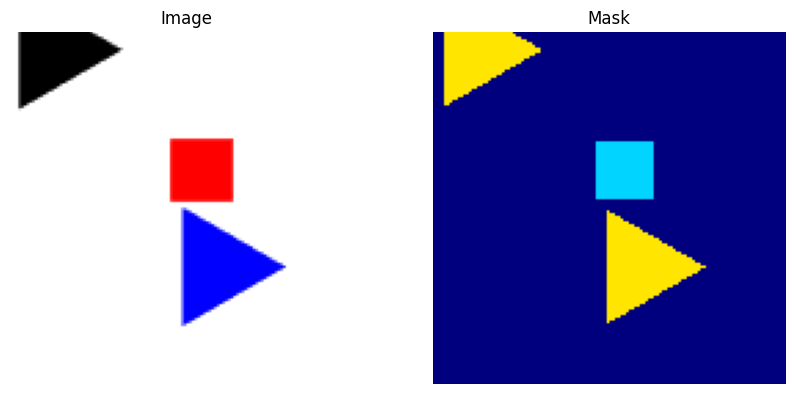

'\nImages are converted to float tensors since neural network layers in PyTorch \noperate on floating-point values, while segmentation masks are kept as long \ntensors because they represent discrete class labels required by the \nCrossEntropy loss.\n'

In [8]:
# -------------------------
# 1) Define transforms
# -------------------------
from torchvision import transforms
# we can also add normalization here

transform = transforms.Compose([
    transforms.ToTensor(),  # turning image into tensor
]) 


# -------------------------
# 2) Create Dataset splits
# -------------------------
train_dataset = FlyingObjectsSegmentation(
    root="/nfs/home/dornor24/datasets/FlyingObjectDataset_10K/FlyingObjectDataset_10K/training",
    transform=transform
)

val_dataset = FlyingObjectsSegmentation(
    root="/nfs/home/dornor24/datasets/FlyingObjectDataset_10K/FlyingObjectDataset_10K/validation",
    transform=transform
)

test_dataset = FlyingObjectsSegmentation(
    root="/nfs/home/dornor24/datasets/FlyingObjectDataset_10K/FlyingObjectDataset_10K/testing",
    transform=transform
)

# -------------------------
# 3) Define DataLoaders
# -------------------------
batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -------------------------
# 4) Visualization
# -------------------------

def visualize_sample(img_tensor, mask_tensor):
    """
    img_tensor: C,H,W float [0,1] یا [0,255]
    mask_tensor: H,W long
    """
    import matplotlib.pyplot as plt
    import numpy as np

    # If the image tensor is in [C, H, W] format, convert it to [H, W, C] format.
    if img_tensor.shape[0] == 3:
        img = img_tensor.permute(1,2,0).cpu().numpy()
    else:
        img = img_tensor.cpu().numpy()
    
    # If the image values are in the [0, 1] range, rescale them to [0, 255]
    if img.max() <= 1.0:
        img = img * 255
    img = img.astype(np.uint8)

    mask = mask_tensor.cpu().numpy()

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap="jet", vmin=0, vmax=3)
    plt.title("Mask")
    plt.axis('off')
    plt.show()

images, masks = next(iter(train_loader))
visualize_sample(images[0], masks[0])

"""
Images are converted to float tensors since neural network layers in PyTorch 
operate on floating-point values, while segmentation masks are kept as long 
tensors because they represent discrete class labels required by the 
CrossEntropy loss.
"""

## Model Description

The model is based on a U-Net-style encoder-decoder convolutional neural network.

The encoder extracts spatial features from the input image by reducing spatial resolution and increasing the number of feature channels. The decoder upsamples these features back to the original image size to produce a pixel-wise segmentation mask.

Skip connections transfer spatial information from the encoder to the decoder. This helps preserve object boundaries and fine-grained details, which are important for segmentation tasks.

The final layer outputs four channels, one for each semantic class.

"During training process the training loss can not only stop decreasing but also go far from a desired value. This occured due to the vanishing gradient. This can be observed as for every layer that we go backwards in the network gradient gets smaller and smaller.

Skip connections in deep architectures, skip some layer in the neural network and feeds the output of one layer as the input to the next layers. This provide an alternative path for the gradient during backpropagation. Therefore, the skip connections help to preserve the gradient.

Skip connections is also very popular for semantic segmentation where information captured in the initial layers also would like to be learned in later layers.
It has been observed that in earlier layers the learned features correspond to lower semantic information that is extracted from the input.

Therefore, for this project I will use skip connections for the auto encoder. More specifically, a U-Net. The skip connections are placed at each step of the encoder and feeding information to the decoder. The size of the input must be the same for both encoder and decoder where skip connections are applied."


In [37]:
# class SimpleModel(nn.Module):
#     def __init__(self, num_classes:int=3,input_shape=(10,10),**kwargs):
#         super(SimpleModel, self).__init__()
        
#         ## Encoder
#         self.conv1 = self.Encoder(num_classes, 32, 7, 3)
#         self.conv2 = self.Encoder(32, 64, 3, 1)
        
#         # Decoder
#         self.upconv2 = self.Decoder(64, 32, 3, 1)
#         self.upconv1 = self.Decoder(32*2, num_classes, 3, 1)

#     def forward(self, x):

#         # Downsample
#         conv1 = self.conv1(x)
#         conv2 = self.conv2(conv1)
        
#         # Upsample
#         upconv2 = self.upconv2(conv2)
#         upconv1 = self.upconv1(torch.cat([upconv2, conv1], 1)) # skip connection

#         return upconv1

#     def Encoder(self, in_channels, out_channels, kernel_size, padding):

#         return nn.Sequential(
#             torch.nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
#             torch.nn.BatchNorm2d(out_channels),
#             torch.nn.ReLU(),
#             torch.nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
#             torch.nn.BatchNorm2d(out_channels),
#             torch.nn.ReLU(),
#             torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
#         )


#     def Decoder(self, in_channels, out_channels, kernel_size, padding):
#         return nn.Sequential(
#             torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=padding),
#             torch.nn.BatchNorm2d(out_channels),
#             torch.nn.ReLU(),
#             torch.nn.Conv2d(out_channels, out_channels, kernel_size, stride=1, padding=padding),
#             torch.nn.BatchNorm2d(out_channels),
#             torch.nn.ReLU(),
#             torch.nn.ConvTranspose2d(out_channels, out_channels, kernel_size=3, stride=2, padding=1, output_padding=1) 
#         )

In [38]:
# You're free to modify this model
# How if we extend the model depth?
### Encoder: 64 → 128 → 256 → 512 → 1024
### Decoder: 512 → 256 → 128 → 64ئ

In [9]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


In [ ]:

class SimpleModel1(nn.Module):
    def __init__(self, num_classes=4, input_channels=3):
        super(SimpleModel1, self).__init__()

        # -------- Encoder --------
        self.conv1 = self.Encoder(input_channels, 64, 3, 1)  # 128 -> 64
        self.conv2 = self.Encoder(64, 128, 3, 1)             # 64 -> 32
        self.conv3 = self.Encoder(128, 256, 3, 1)            # 32 -> 16
        self.conv4 = self.Encoder(256, 512, 3, 1)            # 16 -> 8

        # -------- Bottleneck --------
        self.bottleneck = self.Encoder(512, 1024, 3, 1)      # 8 -> 4

        # -------- Decoder --------
        self.upconv4 = self.Decoder(1024, 512, 3, 1)         # 4 -> 8
        self.upconv3 = self.Decoder(512+512, 256, 3, 1)      # 8 -> 16
        self.upconv2 = self.Decoder(256+256, 128, 3, 1)      # 16 -> 32
        self.upconv1 = self.Decoder(128+128, 64, 3, 1)       # 32 -> 64
        self.upconv0 = nn.ConvTranspose2d(64+64, 64, kernel_size=2, stride=2) # 64 -> 128
        # -------- Final classifier --------
        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)  # 64 -> 128

    def forward(self, x):
        conv1 = self.conv1(x)
        conv2 = self.conv2(conv1)
        conv3 = self.conv3(conv2)
        conv4 = self.conv4(conv3)

        bottleneck = self.bottleneck(conv4)

        up4 = self.upconv4(bottleneck)
        up4 = torch.cat([up4, conv4], dim=1)

        up3 = self.upconv3(up4)
        up3 = torch.cat([up3, conv3], dim=1)

        up2 = self.upconv2(up3)
        up2 = torch.cat([up2, conv2], dim=1)

        up1 = self.upconv1(up2)
        up1 = torch.cat([up1, conv1], dim=1)

        up0 = self.upconv0(up1)  
        
        out = self.final_conv(up0)
        return out

    def Encoder(self, in_channels, out_channels, kernel_size, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def Decoder(self, in_channels, out_channels, kernel_size, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(out_channels, out_channels, kernel_size=2, stride=2)
        )



# I implement a U-Net–like encoder–decoder architecture with skip 
# connections to mitigate the vanishing gradient problem. Downsampling is 
# performed using max-pooling layers instead of strided convolutions. 
# At each encoder stage, feature maps are concatenated with the corresponding 
# decoder stage to preserve low-level spatial information. This is particularly 
# beneficial for semantic segmentation tasks, where fine-grained details captured 
# in early layers are crucial for accurate pixel-wise prediction


In [65]:
# the output size should be the same as the mask
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model0 = SimpleModel1(num_classes=4, input_channels=3).to(device)

# train_loader from 1 batch for test
images, masks = next(iter(train_loader))
images, masks = images.to(device), masks.to(device)

outputs = model0(images)


print("Images shape: ", images.shape)       # [B, C, H, W]
print("Masks shape:  ", masks.shape)        # [B, H, W]
print("Outputs shape:", outputs.shape)      # [B, num_classes, H_out, W_out]

"""

Test of Model Output Shapes

Batch size: 4

Input image size: [4, 3, 128, 128] (Batch, Channels, Height, Width)

Ground truth mask size: [4, 128, 128] (Batch, Height, Width)

Model output size: [4, 4, 128, 128] (Batch, num_classes, Height, Width)

The output model size is equal to mask size and is ready for training and loss computing .

"""

/tmp/ipykernel_2503287/1393089513.py:63: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(self.images[index])
/tmp/ipykernel_2503287/1393089513.py:70: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = imageio.imread(self.masks[index])


Images shape:  torch.Size([4, 3, 128, 128])
Masks shape:   torch.Size([4, 128, 128])
Outputs shape: torch.Size([4, 4, 128, 128])


'\n\nTest of Model Output Shapes\n\nBatch size: 4\n\nInput image size: [4, 3, 128, 128] (Batch, Channels, Height, Width)\n\nGround truth mask size: [4, 128, 128] (Batch, Height, Width)\n\nModel output size: [4, 4, 128, 128] (Batch, num_classes, Height, Width)\n\nThe output model size is equal to mask size and is ready for training and loss computing .\n\n'

In [66]:
"""
Model Architecture:

The model SimpleModel1 is a U-Net style convolutional neural network designed for semantic segmentation with 4 classes. It consists of:
Encoder: Four convolutional blocks (conv1–conv4), each containing two Conv2d layers followed by BatchNorm2d and ReLU, then a MaxPool2d for downsampling. The encoder progressively reduces spatial dimensions while increasing feature channels.
Bottleneck: A convolutional block with higher channel count (1024), serving as the lowest-resolution representation of the input.
Decoder: Four corresponding upsampling blocks (upconv4–upconv1) using ConvTranspose2d for upsampling and skip connections from the encoder blocks to preserve spatial details.
Final Upsampling (upconv0): Additional transposed convolution to match the output size with the input image/mask.
Classifier (final_conv): A 1x1 Conv2d layer that outputs 4 channels corresponding to the 4 segmentation classes.
This architecture allows the model to learn hierarchical features while preserving spatial information via skip connections, which is critical for accurate semantic segmentation.

"""

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleModel1(num_classes=4, input_channels=3).to(device)
print(model)

SimpleModel1(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fal

## Training Function

The training function updates the model parameters using the training dataset.

For each batch, the model predicts a segmentation mask, the loss is computed against the ground-truth mask, and the optimizer updates the model weights.


In [11]:
def train_epoch(model, optimizer, criterion, train_loader, device='cuda'):
    
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks  = masks.to(device)   # [B, H, W], B = batch size, H = Height, W = Weight

        optimizer.zero_grad()

        outputs = model(images)     # [B, num_classes, H, W]

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


    avg_loss = total_loss / len(train_loader)
    return avg_loss

    """
    Args:
        model : nn.Module       -> your segmentation model
        optimizer : torch.optim -> optimizer (e.g., Adam)
        criterion : loss func   -> e.g., nn.CrossEntropyLoss()
        dataloader : DataLoader -> training data
        device : str            -> 'cuda' or 'cpu'

    Returns:
        avg_loss : float        -> average loss over the epoch
    """
# Example usage:
# model = SimpleModel1(num_classes=4).to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# avg_loss = train_epoch(model, optimizer, criterion, train_loader, device)

## Validation During Training

Validation accuracy is computed at the end of each epoch.

During validation, the model is set to evaluation mode and predictions are compared with ground-truth masks at the pixel level. This allows monitoring of how well the model generalizes beyond the training set.


In [12]:
def evaluate(model, val_loader, criterion, device='cuda'):
    model.eval()
    correct_pixels = 0
    total_pixels = 0
    total_loss = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks  = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            preds = torch.argmax(outputs, dim=1)

            correct_pixels += (preds == masks).sum().item()
            total_pixels += masks.numel() # number of elements or the total pixels 
            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    pixel_acc = 100 * correct_pixels / total_pixels

    return avg_loss, pixel_acc

 # pixel Accuracy = the number of pixels which is predicted correctly / the number of whole pixels

"""
When training and validation are implemented as separate functions, the model is
explicitly set to training mode at the beginning of each training epoch. 
Therefore, it is not necessary to manually switch the model back to training mode 
after validation.

"""

'\nWhen training and validation are implemented as separate functions, the model is\nexplicitly set to training mode at the beginning of each training epoch. \nTherefore, it is not necessary to manually switch the model back to training mode \nafter validation.\n\n'

In [ ]:

# # Or we can define the two fundctions again

# def train_epoch_with_val(model, optimizer, criterion,
#                          train_loader, val_loader,
#                          device='cuda'):

#     # -------- TRAIN --------
#     model.train()
#     train_loss = 0.0

#     for images, masks in train_loader:
#         images = images.to(device)
#         masks  = masks.to(device)

#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, masks)
#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)

#     # -------- VALIDATION --------
#     model.eval()
#     val_loss = 0.0
#     correct_pixels = 0
#     total_pixels = 0

#     with torch.no_grad():
#         for images, masks in val_loader:
#             images = images.to(device)
#             masks  = masks.to(device)

#             outputs = model(images)
#             loss = criterion(outputs, masks)
#             val_loss += loss.item()

#             preds = torch.argmax(outputs, dim=1)
#             correct_pixels += (preds == masks).sum().item()
#             total_pixels += masks.numel()

#     val_loss /= len(val_loader)
#     val_acc = 100 * correct_pixels / total_pixels

#     model.train()  # go back to train

#     return train_loss, val_loss, val_acc


# """
# The training and validation phases are combined in a single function per epoch.
# During training, the model is set to training mode and parameters are updated 
# using backpropagation.
# During validation, the model is switched to evaluation mode and pixel-wise accuracy 
# is computed by comparing the predicted class (argmax over class dimension) with the 
# ground truth masks.

# This function extends the training routine implemented in Task 2 by incorporating 
# a validation phase and computing pixel-wise accuracy.
# """
# """
# Pixel-wise accuracy was computed by accumulating the number of correctly 
# classified pixels over the entire validation set and dividing by the total number
# of pixels, which is equivalent to computing argmax over the class dimension and 
# comparing predictions with ground truth masks

# """


In [ ]:
# num_epochs = 15

# for epoch in range(num_epochs):

#     train_loss, val_loss, val_acc = train_epoch_with_val(
#         model,
#         optimizer,
#         criterion,
#         train_loader,
#         val_loader,
#         device
#     )

#     print(
#         f"Epoch [{epoch+1}/{num_epochs}] | "
#         f"Train Loss: {train_loss:.4f} | "
#         f"Val Loss: {val_loss:.4f} | "
#         f"Val Pixel Acc: {val_acc:.2f}%"
#     )


/tmp/ipykernel_188737/1393089513.py:63: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(self.images[index])
/tmp/ipykernel_188737/1393089513.py:70: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = imageio.imread(self.masks[index])


Epoch [1/15] | Train Loss: 0.0216 | Val Loss: 0.0171 | Val Pixel Acc: 99.59%
Epoch [2/15] | Train Loss: 0.0029 | Val Loss: 0.2553 | Val Pixel Acc: 98.74%
Epoch [3/15] | Train Loss: 0.0019 | Val Loss: 0.0423 | Val Pixel Acc: 99.60%
Epoch [4/15] | Train Loss: 0.0009 | Val Loss: 0.0016 | Val Pixel Acc: 99.95%
Epoch [5/15] | Train Loss: 0.0012 | Val Loss: 0.0017 | Val Pixel Acc: 99.95%
Epoch [6/15] | Train Loss: 0.0009 | Val Loss: 0.0060 | Val Pixel Acc: 99.83%
Epoch [7/15] | Train Loss: 0.0006 | Val Loss: 0.0016 | Val Pixel Acc: 99.96%
Epoch [8/15] | Train Loss: 0.0005 | Val Loss: 0.0032 | Val Pixel Acc: 99.91%
Epoch [9/15] | Train Loss: 0.0006 | Val Loss: 0.0013 | Val Pixel Acc: 99.96%
Epoch [10/15] | Train Loss: 0.0002 | Val Loss: 0.0012 | Val Pixel Acc: 99.96%
Epoch [11/15] | Train Loss: 0.0004 | Val Loss: 0.0013 | Val Pixel Acc: 99.96%
Epoch [12/15] | Train Loss: 0.0005 | Val Loss: 0.0013 | Val Pixel Acc: 99.96%
Epoch [13/15] | Train Loss: 0.0002 | Val Loss: 0.0011 | Val Pixel Acc: 99

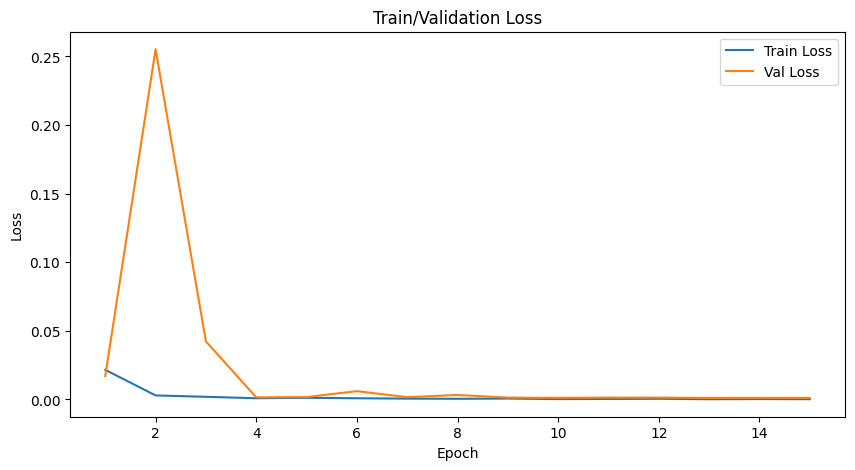

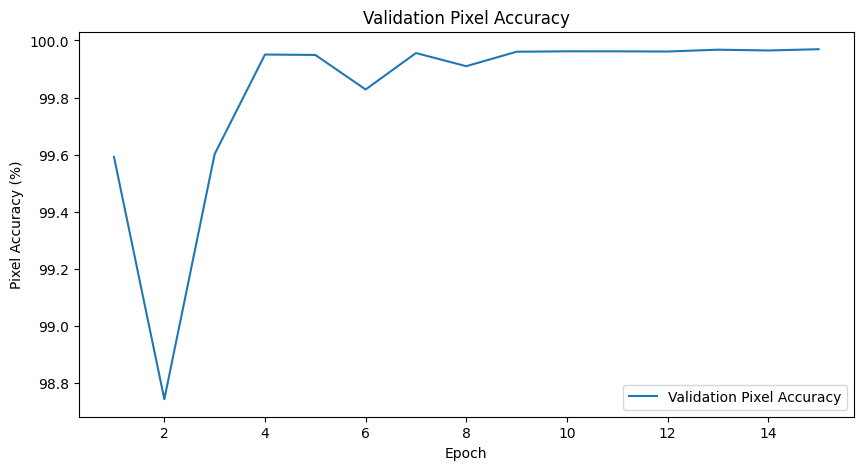

In [28]:
# -------------------------
# 1) Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# 2) Model, Loss, Optimizer
# -------------------------
model = SimpleModel1(num_classes=4, input_channels=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -------------------------
# 3) Hyperparameters
# -------------------------
num_epochs = 15
batch_size = 4  


# -------------------------
# 5) Loop over epochs
# -------------------------
train_losses, val_losses, val_accs = [], [], []

for epoch in range(num_epochs):
    # ---- TRAIN ----
    train_loss = train_epoch(
        model,
        optimizer,
        criterion,
        train_loader,
        device
    )

    # ---- VALIDATION ----
    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    # saving for plot
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Pixel Acc: {val_acc:.2f}%"
    )

# -------------------------
# 6) Plot training curves
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/Validation Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), val_accs, label='Validation Pixel Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Pixel Accuracy (%)')
plt.title('Validation Pixel Accuracy')
plt.legend()
plt.show()


In [ ]:
##Steps

# Train and validate the model using the train_loader and val_loader.
# After training is finished, use the predict function on the test_loader.
# Compute the pixel accuracy and/or the confusion matrix on the test dataset.
# Finally, present the results and plot the required figures.

In [13]:
def predict(model, dataloader, device='cuda'):
    
    model.eval()

    all_preds = []
    all_masks = []

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)


            masks  = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)  # [B, H, W]

            all_preds.append(preds.cpu()) #  #Can't convert CUDA tensor to numpy /preds.cpu() GPU → CPU
            all_masks.append(masks.cpu())

    
    all_preds = torch.cat(all_preds, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    return all_preds, all_masks

 # Returns:
 #        all_preds: torch.Tensor -> predicted masks [N, H, W]
 #        all_masks: torch.Tensor -> ground truth masks [N, H, W]

# for each image in batch / for each pixel / for each class we have a logit:Segmentation → batch-wise dense pixel prediction

# B = 16
# classes = 4
# H = 128
# W = 128

# outputs.shape == [16, 4, 128, 128]


# preds = torch.argmax(outputs, dim=1)
# dim=0 → batch
# dim=1 → classes
# dim=2 → height
# dim=3 → width
# we want to predict the classes for the higher scoree for each pixel so we use dim =1

# in a specific pixel with (i,j) from the picture k:
# outputs[k, :, i, j] = [2.1, -0.3, 5.7, 0.9]

# background: 2.1
# square: -0.3
# triangle: 5.7 the highest
# circular: 0.9

# pred = argmax -> triangle


In [14]:
# -------------------------------
# Confusion matrix for segmentation
# -------------------------------
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def full_confusion_matrix_seg(loader, model, device='cuda'):
    model.eval()
    all_preds = []
    all_masks = []

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1) #for each pixel the class with the maximum logit will be chosen

            all_preds.append(preds.cpu().numpy())
            all_masks.append(masks.cpu().numpy())

    all_preds = np.concatenate([p.flatten() for p in all_preds])
    all_masks = np.concatenate([m.flatten() for m in all_masks])

    # extract classes
    if hasattr(loader.dataset, "get_classes"):
        classes = loader.dataset.get_classes()
    else:
        classes = np.unique(all_masks).tolist()  # fallback

    unique_labels = np.unique(all_masks)
    filtered_classes = [classes[i] for i in unique_labels]

    # Confusion matrix
    cf_matrix = confusion_matrix(all_masks, all_preds, labels=unique_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=filtered_classes)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.show()

    # semantic segmentation report
    print("\n Segmentation Report:\n")
    print(classification_report(all_masks, all_preds, labels=unique_labels, target_names=filtered_classes, digits=4))


In [15]:
def compute_iou_dice(preds, masks, num_classes=4):
    """
    Compute per-class IoU and Dice coefficient
    preds, masks: torch tensors, shape [N, H, W], dtype=long
    num_classes: total number of classes
    """
    ious = []
    dices = []

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        mask_cls = (masks == cls).float()

        intersection = (pred_cls * mask_cls).sum()
        union = pred_cls.sum() + mask_cls.sum() - intersection
        iou = intersection / union if union > 0 else torch.tensor(0.0)
        dice = 2 * intersection / (pred_cls.sum() + mask_cls.sum()) if (pred_cls.sum() + mask_cls.sum()) > 0 else torch.tensor(0.0)

        ious.append(iou.item())
        dices.append(dice.item())

    mean_iou = sum(ious) / num_classes
    mean_dice = sum(dices) / num_classes

    return ious, dices, mean_iou, mean_dice


/tmp/ipykernel_188737/1393089513.py:63: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(self.images[index])
/tmp/ipykernel_188737/1393089513.py:70: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = imageio.imread(self.masks[index])


Test Pixel Accuracy: 99.96%


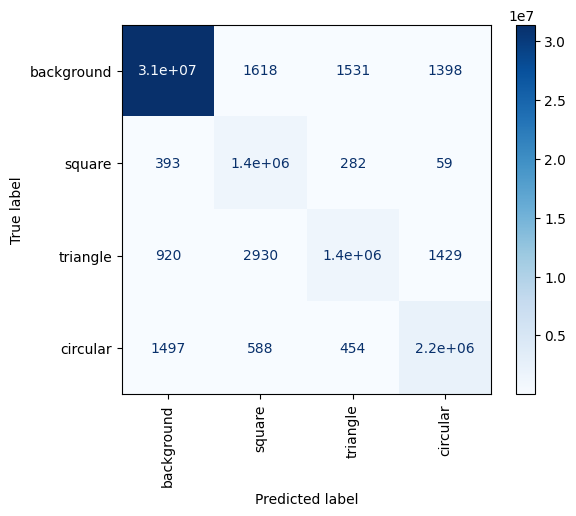


 Segmentation Report:

              precision    recall  f1-score   support

  background     0.9999    0.9999    0.9999  31418517
      square     0.9962    0.9995    0.9978   1351993
    triangle     0.9984    0.9963    0.9974   1427563
    circular     0.9987    0.9988    0.9988   2174407

    accuracy                         0.9996  36372480
   macro avg     0.9983    0.9986    0.9985  36372480
weighted avg     0.9996    0.9996    0.9996  36372480

Class background: IoU = 0.9998, Dice = 0.9999
Class square: IoU = 0.9957, Dice = 0.9978
Class triangle: IoU = 0.9947, Dice = 0.9974
Class circular: IoU = 0.9975, Dice = 0.9988
Mean IoU: 0.9969, Mean Dice: 0.9985


In [51]:
# -------------------------
#Evaluate Prediction on test set
# -------------------------
test_preds, test_masks = predict(model, test_loader, device=device)

# -------------------------
# Compute pixel-wise accuracy
# -------------------------
pixel_acc = 100 * (test_preds == test_masks).sum().item() / test_masks.numel()
print(f"Test Pixel Accuracy: {pixel_acc:.2f}%")

# -------------------------
#  Confusion matrix & semantic segmentation report
# -------------------------
full_confusion_matrix_seg(test_loader, model, device=device)

# -------------------------
# IoU & Dice
# -------------------------
num_classes = len(test_loader.dataset.get_classes())
ious, dices, mean_iou, mean_dice = compute_iou_dice(test_preds, test_masks, num_classes=num_classes)

for idx, cls in enumerate(test_loader.dataset.get_classes()):
    print(f"Class {cls}: IoU = {ious[idx]:.4f}, Dice = {dices[idx]:.4f}")

print(f"Mean IoU: {mean_iou:.4f}, Mean Dice: {mean_dice:.4f}")


In [69]:
import random

def visualize_predictions(model, loader, device, num_samples=3):
    model.eval()
    all_images = []
    all_masks = []
    all_preds = []

    # gathering the all data of a batch
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_images.append(images.cpu())
            all_masks.append(masks.cpu())
            all_preds.append(preds.cpu())

            #if the gathering samples reaches the num_samples then its enough
            if sum([x.size(0) for x in all_images]) >= num_samples:
                break

    # Integrating the batches
    all_images = torch.cat(all_images, dim=0)
    all_masks = torch.cat(all_masks, dim=0)
    all_preds = torch.cat(all_preds, dim=0)

    
    indices = random.sample(range(all_images.size(0)), num_samples)

    for i in indices:
        plt.figure(figsize=(12,4))

        plt.subplot(1,3,1)
        plt.title("Input Image")
        plt.imshow(all_images[i].permute(1,2,0))
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Ground Truth")
        plt.imshow(all_masks[i])
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("Prediction")
        plt.imshow(all_preds[i])
        plt.axis("off")

        plt.show()


/tmp/ipykernel_2503287/1393089513.py:63: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(self.images[index])
/tmp/ipykernel_2503287/1393089513.py:70: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = imageio.imread(self.masks[index])


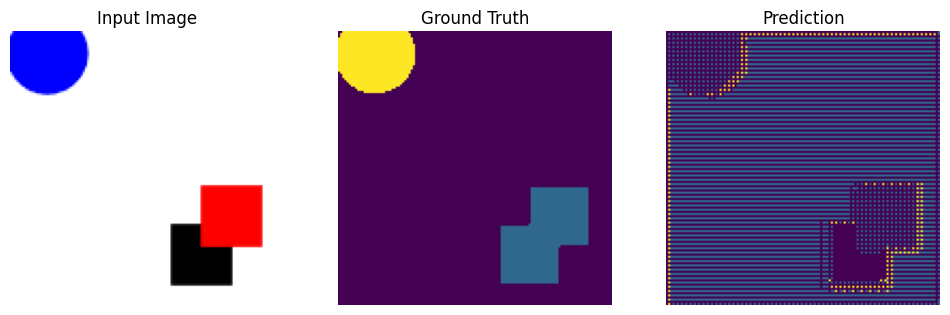

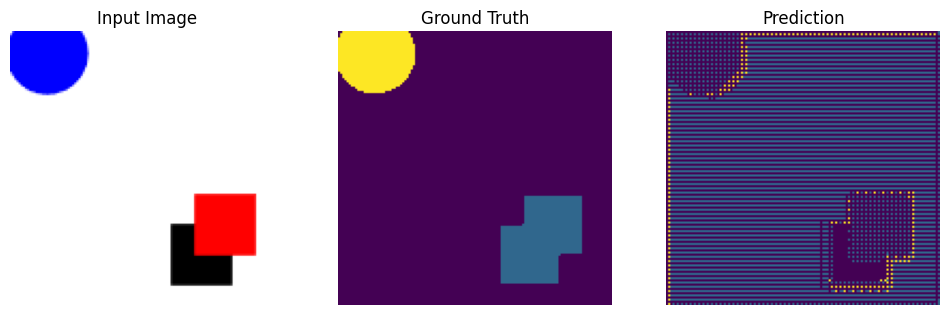

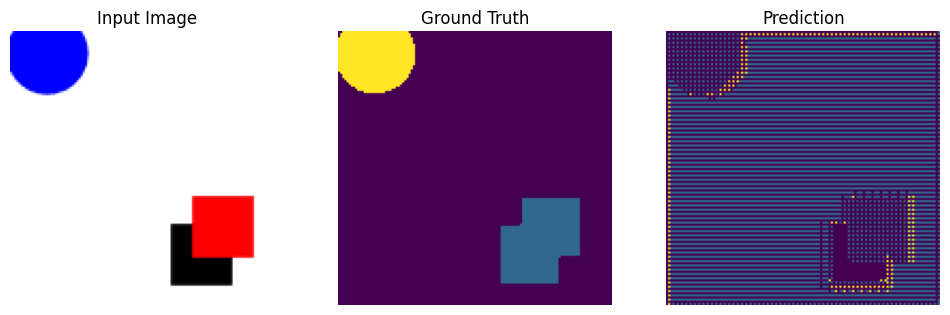

In [70]:
# -------------------------
# Qualitative evaluation on TEST set
# -------------------------
visualize_predictions(
    model,
    test_loader,
    device=device,
    num_samples=3
)


Based on the obtained results:

Test Pixel Accuracy ≈ 99.96%
F1-scores for all classes ≈ 0.997 – 0.999

this indicates that the model has learned the segmentation task almost perfectly.
Therefore, it is expected that:
The predicted segmentation maps are very similar to the ground truth
In some samples, the predictions may even appear almost identical to the ground truth masks

This behavior is not a problem
On the contrary, it is a clear sign of excellent model performance

## Is Pixel Accuracy Enough?
Pixel-wise accuracy provides a general overview of model performance in semantic segmentation, but on its own it is not a fully reliable metric for this task.

## Quantitative and Qualitative Evaluation

Quantitative Comparison:

In our experiments, the model achieves a very high pixel-wise accuracy of 99.96% on the test set. At first glance, this suggests excellent performance. 
However, the dataset is highly imbalanced, with the background class containing a much larger number of pixels than the object classes.
If accuracy were used alone, a model could achieve a high score simply by correctly predicting background pixels, even while performing poorly on smaller object regions.
To address this limitation, we additionally evaluate the model using class-wise precision, recall, and F1-score. 
The segmentation report shows that all object classes (square, triangle, and circular) achieve F1-scores above 0.997, confirming that the high accuracy 
is not misleading in this case and that the model performs well across all classes.

Qualitative Comparison:

From a qualitative perspective, visual inspection of the predicted segmentation masks shows that the model accurately captures object shapes and boundaries. 
Minor errors mainly occur near object edges, which have little impact on pixel accuracy but can significantly affect segmentation quality.    
The strong visual alignment between predicted masks and ground truth labels supports the quantitative results and confirms that the model does not 
merely exploit class imbalance to achieve high accuracy.

Conclusion:

In conclusion, pixel-wise accuracy alone is not sufficient for evaluating semantic segmentation models, especially in the presence of class imbalance. 
However, when combined with class-wise metrics such as precision, recall, F1-score, and confusion matrix analysis, accuracy becomes a useful complementary metric.
In this task, both qualitative and quantitative evaluations indicate that the model performs robustly, and the high accuracy reflects genuine segmentation quality 
rather than a biased prediction toward the background class.
“Therefore, pixel-wise accuracy should be interpreted with caution in semantic segmentation tasks and always be supported by class-wise and region-based metrics.”

## Better Metrics for Semantic Segmentation

Why pixel-wise accuracy alone is not enough:

Pixel-wise accuracy gives a general idea of overall performance, but it can be misleading, especially in datasets with class imbalance. 
For example, the background class dominates most pixels in the Flying Objects dataset. A model could achieve very high accuracy by mainly 
predicting background pixels while performing poorly on smaller objects like squares, triangles, or circles.

Better metrics:

Intersection over Union (IoU / mIoU): Measures overlap between predicted and ground truth regions. A value close to 1 indicates nearly all pixels 
are correctly predicted.
Dice coefficient: Similar to F1-score for segmentation, accounts for both false positives and false negatives.
Per-class precision, recall, and F1-score: Evaluate performance on each object class, highlighting how well small objects are segmented.
    
Pixel-wise accuracy: 99.96%

Per-class Intersection over Union (IoU) and Dice coefficient:

Background: IoU = 0.9998, Dice = 0.9999

Square: IoU = 0.9957, Dice = 0.9978

Triangle: IoU = 0.9947, Dice = 0.9974

Circular: IoU = 0.9975, Dice = 0.9988

Mean IoU: 0.9969

Mean Dice: 0.9985

Interpretation:

Pixel-wise accuracy: 99.96%

Interpretation:

The model correctly predicts nearly all pixels in the test images.
High per-class IoU and Dice show consistent performance across all classes, including smaller objects.
Mean IoU and Dice close to 1 demonstrate robust overall segmentation quality.

Conclusion:
The trained model exhibits near-perfect segmentation performance on the Flying Objects dataset.
Both quantitative metrics (IoU, Dice, F1-score, pixel accuracy) and qualitative inspection confirm that the model accurately segments all object classes
from the background. These results indicate that the model is highly effective for practical semantic segmentation tasks.

## Data Augmentation

Data augmentation is used to increase variation in the training data and improve model robustness.

For semantic segmentation, geometric transformations must be applied to both the input image and the corresponding mask. This ensures that pixel-level labels remain aligned with the objects after transformations such as flipping, rotation, or cropping.


In [25]:
pip install albumentations


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 41.2 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 48.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.0/583.0 kB 13.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 33.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 20.7 MB/s  0:00:00
  Attempting uninstall: numpy1m╸━━━━━━━━━━━━━━━━━━━━━━━━━  4/11 [pydantic-core]ion]
    Found existing installation: numpy 2.3.5m━━━━━━━━━━━━━━━━━━━━━  5/11 [numpy]ore]
    Uninstalling numpy-2.3.5:m╺━━━━━━━━━━━━━━━━━━━━━  5/11 [numpy]
      Successfully uninstalled numpy-2.3.590m━━━━━━━━━━━━━━━━━━━━━  5/11 [numpy]
  You can safely remove it manually.
   ━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━  5/11 [numpy]  WARNING: Failed to remove contents in a temporary directory '/nfs/home/dornor24/conda_envs/deeplearn/lib/pyth

In [ ]:
# I define the Dataset  again
class FlyingObjectsSegmentation(Dataset):
    """
    Dataset class for semantic segmentation of Flying Object images.
    Each pixel in the mask is labeled as classes:
    0: background (BLACK)
    1: square (RED)
    2: triangle (GREEN)
    3: circular (BLUE)
    """

    def __init__(self, root, transform=None):
        super(FlyingObjectsSegmentation, self).__init__()
        self.root = root
        self.transform = transform

        # List all images
        self.images = [os.path.join(dp, f) 
                       for dp, dn, fn in os.walk(os.path.join(root, "image")) 
                       for f in fn if f.endswith(".png")]
        self.images.sort()

        # List all corresponding masks
        self.masks = [os.path.join(dp, f) 
                      for dp, dn, fn in os.walk(os.path.join(root, "gt_image")) 
                      for f in fn if f.endswith(".png")]
        self.masks.sort()

        self.classes = ["background", "square", "triangle", "circular"]

        assert len(self.images) == len(self.masks), "Number of images and masks must match!"

    def __len__(self):
        return len(self.images)

    def _mask_to_class(self, mask):
        """
        Convert RGB mask to class labels per pixel
        0: background (BLACK)
        1: square (RED)
        2: triangle (GREEN)
        3: circular (BLUE)
        """
        h, w, _ = mask.shape
        label = np.zeros((h, w), dtype=np.int64)

        # square -> RED
        label[(mask[:, :, 0] == 255) & (mask[:, :, 1] == 0) & (mask[:, :, 2] == 0)] = 1
        # triangle -> GREEN
        label[(mask[:, :, 0] == 0) & (mask[:, :, 1] == 255) & (mask[:, :, 2] == 0)] = 2
        # circular -> BLUE
        label[(mask[:, :, 0] == 0) & (mask[:, :, 1] == 0) & (mask[:, :, 2] == 255)] = 3
        # background -> BLACK (already 0)

        return label
        

    def get_classes(self):
        return self.classes


    def __getitem__(self, index):
        #1)Load image & mask
        img = imageio.imread(self.images[index])        # H×W×3
        mask_rgb = imageio.imread(self.masks[index])    # H×W×3
    
        #2)Apply Albumentations (if any)
        if self.transform:
            augmented = self.transform(image=img, mask=mask_rgb)
            img = augmented["image"]
            mask_rgb = augmented["mask"]
    
        #3)Convert RGB mask → class labels
        mask_class = self._mask_to_class(mask_rgb)
    
        #4)Convert image to tensor
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask_class = torch.from_numpy(mask_class).long()
    
        return img, mask_class


In [51]:
#Albumentations Transform for train datast
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform_aug = A.Compose([
    A.RandomResizedCrop(size=(128, 128), scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.GaussianBlur(blur_limit=3, p=0.3),
])
# Q: If the image size is already 128×128, what does RandomResizedCrop do?

# it still plays an important role.
# First, a random crop of the image is taken
# e.g., 80% or 90% of the original image.
# Then, it is resized back to 128×128.

# As a result:
# Part of the image is removed.
# The object may:
# Shift slightly in position
# Be partially cropped
# Appear larger or smaller
# The model becomes more scale-invariant and location-robust.

In [52]:
#Transform for test/ validation with out augmentation

val_test_transform = A.Compose([
    A.Resize(128, 128),
])


In [53]:
# -------------------------
#  Create new Dataset splits
# -------------------------
train_dataset_aug = FlyingObjectsSegmentation(
root="/nfs/home/dornor24/datasets/FlyingObjectDataset_10K/FlyingObjectDataset_10K/training",
    transform=train_transform_aug
)

val_dataset_aug = FlyingObjectsSegmentation(
root="/nfs/home/dornor24/datasets/FlyingObjectDataset_10K/FlyingObjectDataset_10K/validation",
    transform=val_test_transform
)

test_dataset_aug = FlyingObjectsSegmentation(
root="/nfs/home/dornor24/datasets/FlyingObjectDataset_10K/FlyingObjectDataset_10K/testing",
    transform=val_test_transform
)

# -------------------------
#  Define DataLoaders
# -------------------------

train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
val_loader_aug   = DataLoader(val_dataset_aug, batch_size=batch_size, shuffle=False)
test_loader_aug  = DataLoader(test_dataset_aug, batch_size=batch_size, shuffle=False)

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [54]:

# -------------------------
#  Model, Loss, Optimizer
# -------------------------
model_aug = SimpleModel1(num_classes=4, input_channels=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3)

# -------------------------
#  Hyperparameters
# -------------------------
num_epochs = 15
batch_size = 4  


# -------------------------
#  Loop over epochs
# -------------------------
train_losses_aug, val_losses_aug, val_accs_aug = [], [], []

for epoch in range(num_epochs):
    # ---- TRAIN ----
    train_loss = train_epoch(
        model_aug,
        optimizer_aug,
        criterion,
        train_loader_aug,
        device
    )

    # ---- VALIDATION ----
    val_loss, val_acc = evaluate(
        model_aug,
        val_loader_aug,
        criterion,
        device
    )

    # saving for plot
    train_losses_aug.append(train_loss)
    val_losses_aug.append(val_loss)
    val_accs_aug.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Pixel Acc: {val_acc:.2f}%"
    )



/tmp/ipykernel_2503287/673652050.py:64: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(self.images[index])        # H×W×3
/tmp/ipykernel_2503287/673652050.py:65: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask_rgb = imageio.imread(self.masks[index])    # H×W×3


Epoch [1/15] | Train Loss: 0.0824 | Val Loss: 0.0209 | Val Pixel Acc: 99.38%
Epoch [2/15] | Train Loss: 0.0306 | Val Loss: 0.0148 | Val Pixel Acc: 99.47%
Epoch [3/15] | Train Loss: 0.0274 | Val Loss: 0.0140 | Val Pixel Acc: 99.54%
Epoch [4/15] | Train Loss: 0.0249 | Val Loss: 0.0125 | Val Pixel Acc: 99.58%
Epoch [5/15] | Train Loss: 0.0232 | Val Loss: 0.0121 | Val Pixel Acc: 99.59%
Epoch [6/15] | Train Loss: 0.0227 | Val Loss: 0.0129 | Val Pixel Acc: 99.58%
Epoch [7/15] | Train Loss: 0.0218 | Val Loss: 0.0108 | Val Pixel Acc: 99.67%
Epoch [8/15] | Train Loss: 0.0210 | Val Loss: 0.0107 | Val Pixel Acc: 99.68%
Epoch [9/15] | Train Loss: 0.0206 | Val Loss: 0.0118 | Val Pixel Acc: 99.58%
Epoch [10/15] | Train Loss: 0.0203 | Val Loss: 0.0104 | Val Pixel Acc: 99.69%
Epoch [11/15] | Train Loss: 0.0199 | Val Loss: 0.0105 | Val Pixel Acc: 99.66%
Epoch [12/15] | Train Loss: 0.0196 | Val Loss: 0.0098 | Val Pixel Acc: 99.75%
Epoch [13/15] | Train Loss: 0.0193 | Val Loss: 0.0101 | Val Pixel Acc: 99

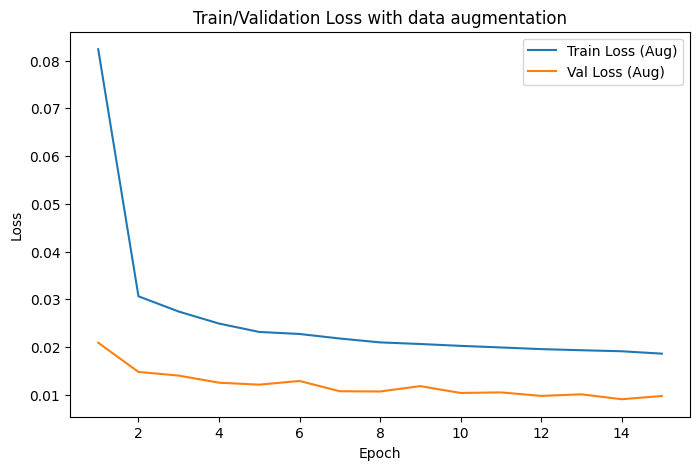

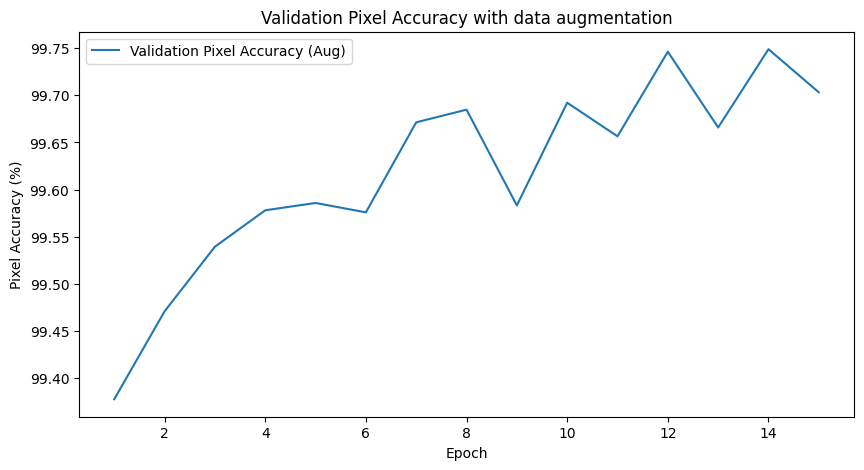

In [55]:
# -------------------------
#  Plot training curves
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses_aug, label='Train Loss (Aug)')
plt.plot(range(1, num_epochs+1), val_losses_aug, label='Val Loss (Aug)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/Validation Loss with data augmentation')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(range(1, num_epochs+1), val_accs_aug, label='Validation Pixel Accuracy (Aug)')
plt.xlabel('Epoch')
plt.ylabel('Pixel Accuracy (%)')
plt.title('Validation Pixel Accuracy with data augmentation')
plt.legend()
plt.show()


In [56]:
# -------------------------
#  Testing
# -------------------------

test_preds_aug, test_masks_aug = predict(
    model_aug, test_loader_aug, device
)
# -------------------------
# Compute pixel-wise accuracy
# -------------------------
pixel_acc_aug = 100 * (test_preds_aug == test_masks_aug).sum().item() / test_masks_aug.numel()
print(f"[AUG] Test Pixel Accuracy: {pixel_acc_aug:.2f}%")


/tmp/ipykernel_2503287/673652050.py:64: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(self.images[index])        # H×W×3
/tmp/ipykernel_2503287/673652050.py:65: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask_rgb = imageio.imread(self.masks[index])    # H×W×3


[AUG] Test Pixel Accuracy: 99.73%


/tmp/ipykernel_2503287/673652050.py:64: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(self.images[index])        # H×W×3
/tmp/ipykernel_2503287/673652050.py:65: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask_rgb = imageio.imread(self.masks[index])    # H×W×3


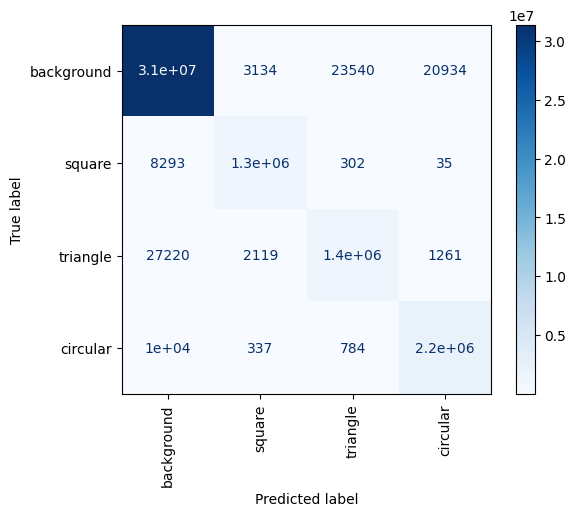


 Segmentation Report:

              precision    recall  f1-score   support

  background     0.9985    0.9985    0.9985  31418517
      square     0.9959    0.9936    0.9947   1351993
    triangle     0.9827    0.9786    0.9806   1427563
    circular     0.9898    0.9947    0.9923   2174407

    accuracy                         0.9973  36372480
   macro avg     0.9917    0.9913    0.9915  36372480
weighted avg     0.9973    0.9973    0.9973  36372480

Class background: IoU = 0.9970, Dice = 0.9985
Class square: IoU = 0.9895, Dice = 0.9947
Class triangle: IoU = 0.9620, Dice = 0.9806
Class circular: IoU = 0.9846, Dice = 0.9923
Mean IoU: 0.9833, Mean Dice: 0.9915


In [58]:
# -------------------------
#  Confusion matrix & semantic segmentation report
# -------------------------
full_confusion_matrix_seg(test_loader_aug, model_aug, device=device)

# -------------------------
# IoU & Dice
# -------------------------
num_classes = len(test_loader_aug.dataset.get_classes())
ious, dices, mean_iou, mean_dice = compute_iou_dice(test_preds_aug, test_masks_aug, num_classes=num_classes)

for idx, cls in enumerate(test_loader_aug.dataset.get_classes()):
    print(f"Class {cls}: IoU = {ious[idx]:.4f}, Dice = {dices[idx]:.4f}")

print(f"Mean IoU: {mean_iou:.4f}, Mean Dice: {mean_dice:.4f}")

/tmp/ipykernel_2503287/673652050.py:64: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread(self.images[index])        # H×W×3
/tmp/ipykernel_2503287/673652050.py:65: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask_rgb = imageio.imread(self.masks[index])    # H×W×3


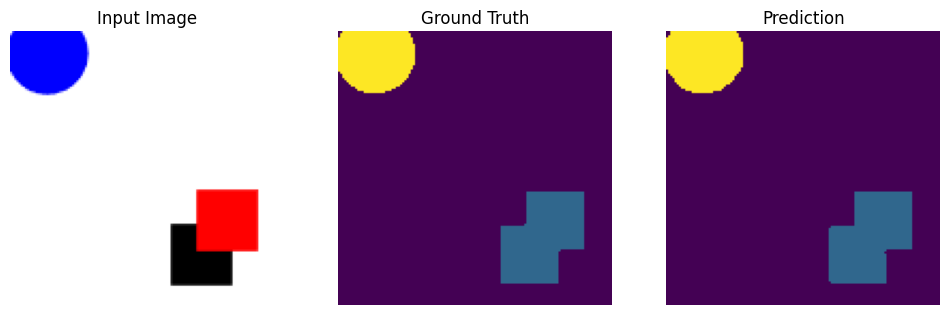

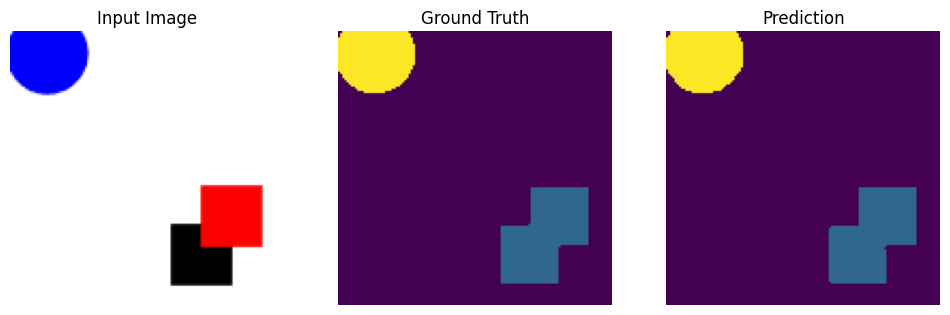

In [74]:
# -------------------------
# Qualitative evaluation on TEST set
# -------------------------
visualize_predictions(
    model_aug,
    test_loader_aug,
    device=device,
    num_samples=2
)

## Data Augmentation Results and Conclusion

During this project, I explored various image transformations using the Albumentations library
Albumentations provides an extensive set of fast and flexible image augmentation techniques specifically designed for computer vision tasks, including semantic segmentation

I applied geometric data augmentations (RandomHorizontalFlip, RandomRotation, RandomResizedCrop, Resize) using Albumentations to jointly transform 
images and masks. This improved model robustness to orientation, scale, and spatial variation. While pixel accuracy, IoU, and Dice slightly decreased
compared to the non-augmented model, training stability and generalization improved, making the augmented model more reliable for unseen data.”

Why Albumentations and its benefits:

It supports simultaneous transformations on images and their corresponding segmentation masks. This ensures that any augmentation applied to the input 
image (e.g., flips, rotations, resizing) is also applied consistently to the mask, which is essential for pixel-wise tasks

Applied transformations in this project:

RandomResizedCrop – helps the model generalize to objects appearing at different scales and positions.
HorizontalFlip and VerticalFlip – introduce invariance to orientation.
Rotate – makes the model robust to rotated objects.
GaussianBlur – adds minor image noise, improving generalization


Effect of augmentation on results:
By comparing the training without augmentation vs. with augmentation, we observe the following:


| Metric              | Without Augmentation           | With Augmentation              |
| ------------------- | ------------------------------ | ------------------------------ |
| Test Pixel Accuracy | 99.96%                         | 99.73%                         |
| Mean IoU            | 0.9969                         | 0.9833                         |
| Mean Dice           | 0.9985                         | 0.9915                         |
| Per-class IoU       | Slightly higher on all classes | Slightly lower but more robust |
| Per-class F1        | Very high                      | Very high                      |

Although the pixel accuracy slightly decreased with augmentation, this is expected because augmentation introduces more challenging samples 
(rotations, crops, flips).
The model trained with augmentation becomes more robust to variations in object position, scale, and orientation.
The high F1-scores (0.980 – 0.998) and IoU (>0.96 for all classes) indicate that augmentation did not degrade performance but improved generalization 
potential.

Conclusion:

Albumentations transformations were useful for this semantic segmentation task because they provided robust data augmentation for both images and masks.
Despite a minor drop in metrics like pixel accuracy and mean IoU, the model trained with augmentation is less likely to overfit and will generalize 
better to unseen variations of flying objects.
Using Albumentations is recommended whenever segmentation datasets are limited or need more variability to improve the model’s robustness.